# <a href="https://thetahat.ru/courses/ad" target="_top">Введение в анализ данных</a>
## Домашнее задание 7. Кластеризация и понижение размерности

**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить телеграм-боту `@thetahat_ds25_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайн см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**. Если вы строите интерактивные графики, их стоит прислать в формате html.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания всем участникам списывания дается штраф -2 балла к итоговой оценке за семестр.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.

**Правила оформления теоретических задач:**

* Решения необходимо оформить в виде $\LaTeX$ в markdown-ячейках. Иные способы (в т.ч. фотографии) не принимаются.
* Если вы не знаете $\LaTeX$, используйте ИИ-инструменты для оформления черновика решения. Примеры были показаны на лекции 2 по ИИ-инструментам.
* **В решениях поясняйте, чем вы пользуетесь**, хотя бы кратко.
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.


<b><font size="5" color="red">Важно!!! Правила заполнения ноутбука:</font></b>
* Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения задач.
* Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз.
* Отвечайте на вопросы, а также добавляйте новые ячейки в предложенных местах, которые обозначены `...`.
* В markdown-ячейка, содержащих описание задачи, находятся специальные отметки, которые <font color="red"><b>запрещается модифицировать</b></font>.
* При нарушении данных правил работа может получить 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash; 30 баллов
* Задача 2 &mdash; 30 баллов
* Задача 3 &mdash; 120 баллов

Баллы учитываются в <b><font color="green">факультативной части</font></b> курса и не влияют на оценку по основной части.

In [ ]:
# Bot check

# HW_ID: fpmi_ad7
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

При необходимости установите библиотеку-расширение для `plotly`, позволяющую рисовать картинки на всплывающих окнах.

    pip install dash

In [1]:
!pip install dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 11.7 MB/s eta 0:00:00
  Attempting uninstall: Werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: Flask
    Found existing installation: Flask 3.1.0
    Uninstalling Flask-3.1.0:
      Successfully uninstalled Flask-3.1.0


In [2]:
!pip install plotly

In [3]:
pip install transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [4]:
import io
import os
import base64
from typing import Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
from tqdm.cli import tqdm
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import plotly.express as px
from dash import Dash, dcc, html, Input, Output, no_update, callback
import plotly.graph_objects as go
import plotly.express as px
import plotly.offline as pyo
import plotly

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import torch
from transformers import ViTImageProcessor, ViTModel, AutoFeatureExtractor
from sklearn.metrics.pairwise import euclidean_distances
import scipy.stats as sps
from scipy.stats import gaussian_kde
from transformers import ViTImageProcessor, ViTModel

from sklearn.decomposition import PCA
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import cv2
import imageio
from IPython.display import Image

from PIL import Image
import requests

sns.set_theme(style="darkgrid", palette="Set2")

<font size="4"><b>Внимание! Файл с решением может быть тяжелым. Если он весит 20 Мб и более, заранее разделите его на несколько частей.</b></font>

---
### Задача 3.

> *Возможно, эту задачу будет оптимальнее сделать в отдельном файле или после перезапуска ядра. Если не хватает оперативки, попробуйте использовать более простые модели. Если все равно не помогает &mdash; спросите в чате.*

В этой задаче мы попробуем кластеризовать различными способами изображения котиков из датасета с <a href="https://thetahat.ru/courses/ad/main/7/pca" target="_top">семинара</a>.

Скачайте данные, загрузите их и отрисуйте несколько примеров. Если вы используете Colab, оптимальнее всего будет закинуть zip-архив `cats.zip` в файловое пространство (кнопка папки на левой панели) и распаковать его с помощью `!unzip cats.zip`.

In [5]:
from google.colab import files
uploaded = files.upload()  # Выберите ZIP-архив

Saving cats.zip to cats.zip


In [6]:
!unzip cats.zip -d /content/cats

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: /content/cats/cats/1428.jpg  
  inflating: /content/cats/cats/9074.jpg  
  inflating: /content/cats/cats/15244.jpg  
  inflating: /content/cats/cats/15536.jpg  
  inflating: /content/cats/cats/9921.jpg  
  inflating: /content/cats/cats/631.jpg  
  inflating: /content/cats/cats/11208.jpg  
  inflating: /content/cats/cats/12067.jpg  
  inflating: /content/cats/cats/6179.jpg  
  inflating: /content/cats/cats/10880.jpg  
  inflating: /content/cats/cats/11546.jpg  
  inflating: /content/cats/cats/3015.jpg  
  inflating: /content/cats/cats/8801.jpg  
  inflating: /content/cats/cats/13392.jpg  
  inflating: /content/cats/cats/12926.jpg  
  inflating: /content/cats/cats/15091.jpg  
  inflating: /content/cats/cats/10857.jpg  
  inflating: /content/cats/cats/14576.jpg  
  inflating: /content/cats/cats/6025.jpg  
  inflating: /content/cats/cats/2243.jpg  
  inflating: /content/cats/cats/10704.jpg  
  inflating: /cont

Размерность cats: (15747, 12288)


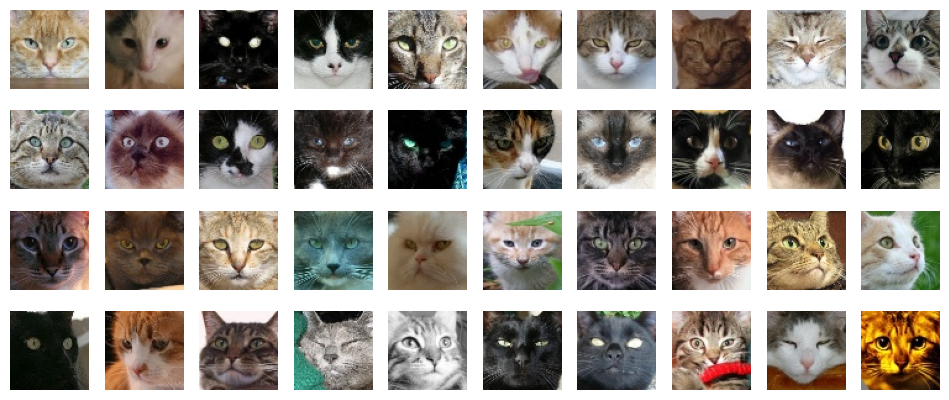

In [7]:
# Загружаем картинки
# ...
cats_path = "/content/cats/cats"
cats = []

for filename in os.listdir(cats_path):
    cats.append(plt.imread(os.path.join(cats_path, filename)))

cats = np.stack(cats).reshape(-1, 64 * 64 * 3)
print(f"Размерность cats: {cats.shape}")

# Визуализируем примеры
plt.figure(figsize=(12, 5))
for i in range(40):
    plt.subplot(4, 10, i + 1)
    plt.imshow(cats[i].reshape(64, 64, 3))
    plt.axis("off")

#### 1. Свойства метрики в пространстве котиков

Прежде всего давайте исследуем, наблюдается ли проблема проклятия размерности в пространстве котиков, фактически повторив исследование предыдущей задачи. Для этого выберите не менее 10000 случайных пар изображений и посчитайте расстояния между ними. Визуализируйте гистограмму или <a href="https://thetahat.ru/courses/python/07" target="_top">KDE-оценку плотности</a> нормированных расстояний.

Повторите те же действия к результату применения PCA, рассмотрев разное количество компонент, например, для 30, 100 и 500. Обратите внимание, что PCA нужно обучать на всех изображениях, а не только для тех, для которых вы будете считать расстояния. Примеры обучения PCA можно посмотреть в <a href="https://thetahat.ru/courses/ad/main/7/pca" target="_top">ноутбуке</a> с занятия.

Функция для подсчета расстояний между 10000 случайными парами изображений

In [8]:
def rand_norm_dist(vectors):
  id_1 = np.random.choice(vectors.shape[0], 10000)
  id_2 = np.random.choice(vectors.shape[0], 10000)
  x = vectors[id_1]
  y = vectors[id_2]
  res = np.zeros(10000)
  for i in range(10000 - 1):
    res[i] = np.linalg.norm(x[i] - y[i])
  res /= np.mean(res)
  return res

Сделаем проекцию из исходного 12288-мерного пространства в 30-мерное, 100-мерное и 500-мерное  с помощью PCA

In [9]:
pca_30 = PCA(n_components=30)
cats_projection_30 = pca_30.fit_transform(cats.astype(np.float32))

pca_100 = PCA(n_components=100)
cats_projection_100 = pca_100.fit_transform(cats.astype(np.float32))

pca_500 = PCA(n_components=500)
cats_projection_500 = pca_500.fit_transform(cats.astype(np.float32))

Подсчитаем расстояния

In [10]:
distances_30 = rand_norm_dist(cats_projection_30)
distances_100 = rand_norm_dist(cats_projection_100)
distances_500 = rand_norm_dist(cats_projection_500)
distances_12288 = rand_norm_dist(cats)

Визуализируем KDE-оценки

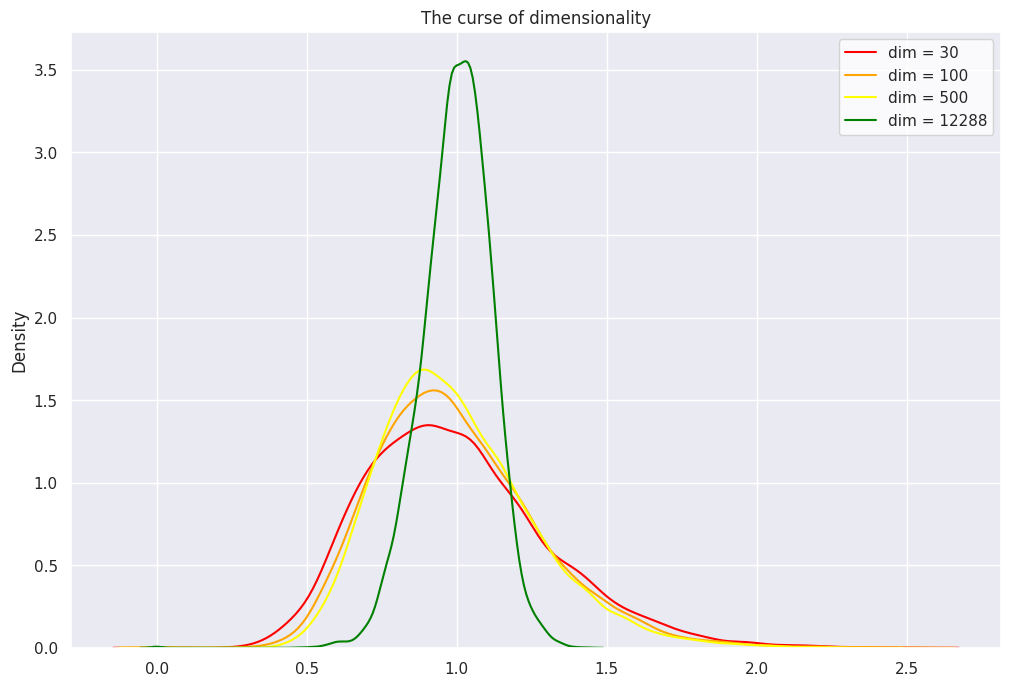

In [11]:
plt.figure(figsize=(12, 8))
with sns.axes_style("darkgrid"):
    ax = sns.kdeplot(distances_30, label="dim = 30", color='Red')
    ax = sns.kdeplot(distances_100, label="dim = 100", color='Orange')
    ax = sns.kdeplot(distances_500, label="dim = 500", color='Yellow')
    ax = sns.kdeplot(distances_12288, label="dim = 12288", color='Green')
    ax.set_title("The curse of dimensionality");
    ax.legend().get_frame().set_facecolor("white");

Сделайте выводы

По графику можно наблюдать проклятие размерности. Оно немного менее выраженное по сравнению со второй задачей. Также наблюдается смещение пиков влево от единицы.

#### 2. Кластеризация котиков по вектору изображения

Начнем эксперименты с самого простого способа: каждое изображение можно вытянуть в вектор размерности $64 \cdot 64 \cdot 3$, их и попытаемся кластеризовать. Обучите по этим объектам метод KMeans из sklearn, пример можно посмотреть в <a href="https://thetahat.ru/courses/ad/main/7/clustering" target="_top">ноутбуке</a> по кластеризации

In [12]:
%%time
kmeans = KMeans(n_clusters=6, n_init="auto", random_state=42)
kmeans.fit(cats)
y_pred = kmeans.predict(cats)

CPU times: user 25.5 s, sys: 2.04 s, total: 27.6 s
Wall time: 26 s


Теперь отобразим изображения на плоскость с помощью PCA и визуализируем полученные предсказания цветом, как это было сделано на <a href="https://thetahat.ru/courses/ad/main/7/clustering" target="_top">семинаре</a> для ответов на вопросы в бот. Ниже уже реализована функция отрисовки `visualize_images_clusterisation`, вам требуется лишь применить PCA и вызвать функцию с правильными параметрами.

> В процессе работы над заданием для детального исследования кластеров стоит передавать `use_dash=True`, в этом случае всё будет рисоваться со всплывающими картинками. А в конце, **перед сдачей работы, необходимо перерисовать графики с `use_dash=False`**, тогда они нарисуются с помощью простого plotly и сохранятся в ноутбуке
>
> Если вы работаете в Colab, и с опцией `use_dash=False` у вас не отрисовывается график, попробуйте посмотреть решение проблемы <a href="https://stackoverflow.com/questions/47230817/plotly-notebook-mode-with-google-colaboratory" target="_top">тут</a>.
>
> Если вы работаете в Jupyter Notebook, и у вас не отображаются графики, попробуйте нажать кнопку `Not Trusted` на верхней панели справа.
>
> Если совсем никак не получается, сохраните графики в html и отправьте боту.

In [13]:
def visualize_images_clusterisation(
    images: np.ndarray,
    projection: np.ndarray,
    clusters: np.ndarray,
    port: Optional[int] = None,
    use_dash: bool = False,
) -> Optional[Dash]:
    """
    Визуализирует кластеризацию изображений с возможностью просмотра изображений при наведении.

    Создает интерактивный scatter plot проекции изображений с двумя режимами:
    1. Режим Jupyter (use_dash=False): показывает статичный plotly график
    2. Режим Dash (use_dash=True): запускает интерактивный сервер с hover-эффектом

    Параметры:
        images: Массив изображений формы (n_samples, height, width, channels)
        projection: 2D проекция эмбеддингов формы (n_samples, 2)
        clusters: Массив меток кластеров формы (n_samples,)
        port: Порт для запуска Dash-приложения (None - случайный порт)
        use_dash: Флаг использования интерактивного Dash-режима

    Возвращает:
        При use_dash=True возвращает Dash приложение, иначе None
    """

    plotly.offline.init_notebook_mode()

    # Рисуем график с точками как на семинаре
    fig = px.scatter(
        x=projection[:, 0],
        y=projection[:, 1],
        hover_name=clusters,
        hover_data={"image_idx": list(range(len(images)))},
        color=clusters.astype(str),
        width=1000,
        height=800,
        title="PCA проекция изображений на плоскость",
        size=[1] * len(images),
        size_max=12,
    )

    if not use_dash:
        fig.show()
        return

    # Добавляем во всплывающее окошко (hover box) изображения
    fig.update_traces(
        hoverinfo="none",
        hovertemplate=None,
    )

    app = Dash(__name__)

    app.layout = html.Div(
        className="container",
        children=[
            dcc.Graph(id="graph-2-dcc", figure=fig, clear_on_unhover=True),
            dcc.Tooltip(id="graph-tooltip-2", direction="bottom"),
        ],
    )

    @callback(
        Output("graph-tooltip-2", "show"),
        Output("graph-tooltip-2", "bbox"),
        Output("graph-tooltip-2", "children"),
        Output("graph-tooltip-2", "direction"),
        Input("graph-2-dcc", "hoverData"),
    )
    def display_hover(
        hoverData: Optional[Dict],
    ) -> Tuple[bool, Union[Dict, str], List[html.Img], str]:
        """
        Callback функция для обработки hover-событий и отображения изображений во всплывающем окне.

        Параметры:
            hoverData: Данные о точке, на которую наведен курсор. Содержит:
                      - coordinates (координаты точки)
                      - pointIndex (индекс точки)
                      - bbox (границы точки)
                      - customdata (дополнительные данные)

        Возвращает кортеж:
            1. Флаг показа/скрытия tooltip (bool)
            2. Bounding box точки (dict) или no_update
            3. Список HTML-элементов для отображения (List[html.Img])
            4. Направление отображения tooltip (str)
        """
        if hoverData is None:
            return False, no_update, no_update, no_update

        # Достаем индекс картинки, который выше положили в hover_data
        hover_data = hoverData["points"][0]
        image_idx = hover_data["customdata"][0]
        # И получаем само изображение кота
        image = Image.fromarray(images[image_idx].reshape(64, 64, 3))

        # Преобразовываем изображение в base64 кодировку
        buffer = io.BytesIO()
        image.save(buffer, format="jpeg")
        encoded_image = base64.b64encode(buffer.getvalue()).decode()
        image_url = "data:image/jpeg;base64, " + encoded_image

        image_children = [
            html.Img(
                src=image_url,
                style={"width": "196px"},
            ),
        ]

        return True, hover_data["bbox"], image_children, "top"

    if port is None:
        port = str(np.random.randint(5000, 15000))
    app.run(port=port, debug=True, jupyter_height=800)

    return app

In [14]:
pca_2 = PCA(n_components=2)
cats_projection_2 = pca_2.fit_transform(cats.astype(np.float32))

In [17]:
def configure_plotly_browser_state():
  import IPython
  display(IPython.core.display.HTML('''
        <script src="/static/components/requirejs/require.js"></script>
        <script>
          requirejs.config({
            paths: {
              base: '/static/base',
              plotly: 'https://cdn.plot.ly/plotly-latest.min.js?noext',
            },
          });
        </script>
        '''))

In [35]:
import plotly.graph_objects as go
configure_plotly_browser_state()
# visualize_images_clusterisation(cats, cats_projection_2, y_pred, use_dash=False)

# task7_1.png

Для каждого кластера нарисуйте по 5-10 типичных изображений, то есть ближайших к центру кластера. Похожую операцию мы видели на занятии в <a href="https://thetahat.ru/courses/ad/main/7/clustering" target="_top">ноутбуке</a> по кластеризации.

*Примечание.* Для одного кластера рисуйте картинки "в строчку". Так будет удобно как вам самим, так и проверяющему. Примеры можно посмотреть в <a href="https://thetahat.ru/courses/ad/main/7/pca" target="_top">ноутбуке</a> по PCA.

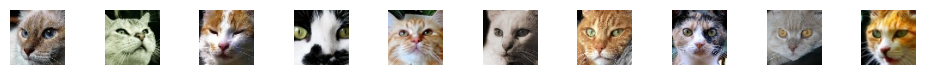

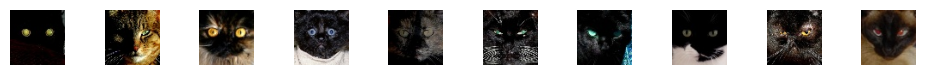

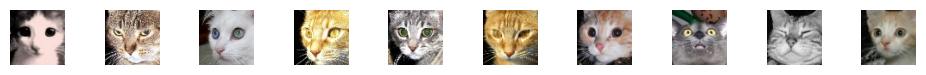

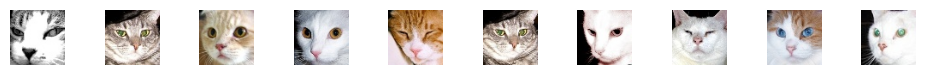

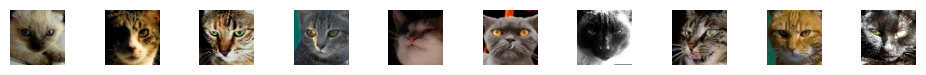

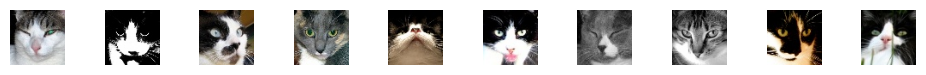

In [19]:
for cluster in np.unique(y_pred):
    cluster_points = cats_projection_2[y_pred == cluster]
    cluster_answers = cats[y_pred == cluster]

    # Находим центр кластера
    cluster_center = cluster_points.mean(axis=0)
    # Считаем расстояния до центра от каждой точки кластера
    distances = np.linalg.norm(cluster_center - cluster_points, axis=1)
    # Сортируем расстояния и берем индексы в порядке возрастания расстояний
    closest_idxs = np.argsort(distances)
    # Берем топ-5 уникальных ответов, соответствующих полученным индексам
    closest_answers = np.unique(cluster_answers[closest_idxs], axis = 0)[:10]


    plt.figure(figsize=(12,5))
    for i in range(10):
        plt.subplot(6, 10, i + 1)
        plt.imshow(closest_answers[i].reshape(64, 64, 3))
        plt.axis("off")

Наблюдаются ли какие-то закономерности в изображениях внутри одного кластера? Если да, то опишите отличительные черты кластеров.

Да, во втором кластере черные коты с выделяющимися глазками.
В четвёртом кластере белые коты.
В последнем кластере коты оттенков серого.

Подумайте, чем может быть плох такой подход? Какая проблема могла возникнуть и возникла ли? Обратите внимание на проведенное ранее исследование.

Подход плох в большой размерности вкупе с проклятием размерности. Нет четкой ясности в количестве классов.

#### 3. PCA + кластеризация

Попробуем уменьшить размерность перед кластеризацией с помощью PCA, спроектировав изображения на первые несколько главных компонент

**Примечание.** Не стоит брать больше 100 главных компонент

Сделайте кластеризацию:

In [20]:
pca_50 = PCA(n_components=50)
cats_projection_50 = pca_50.fit_transform(cats.astype(np.float32))

In [21]:
%%time
kmeans = KMeans(n_clusters=6, n_init="auto", random_state=42)
kmeans.fit(cats_projection_50)
y_pred = kmeans.predict(cats_projection_50)

CPU times: user 86.8 ms, sys: 0 ns, total: 86.8 ms
Wall time: 86.8 ms


Визуализируйте полученные кластера:

In [36]:
pca_2 = PCA(n_components=2)
cats_projection_2 = pca_2.fit_transform(cats_projection_50.astype(np.float32))

configure_plotly_browser_state()
# visualize_images_clusterisation(cats,cats_projection_2,y_pred, use_dash=False)

#task7_2.png

Нарисуйте по 5-10 типичных изображений для новых кластеров

In [23]:
# Функция для нахождения и визуализации типичных изображений для каждого кластера
def visualize_typical_images(images, labels, n_images_per_cluster=5):
    unique_labels = np.unique(labels)
    fig, axes = plt.subplots(len(unique_labels), n_images_per_cluster, figsize=(15, 10))

    for i, label in enumerate(unique_labels):
        cluster_indices = np.where(labels == label)[0]
        cluster_images = images[cluster_indices]

        # Выбираем n_images_per_cluster изображений, наиболее близких к центроиду
        centroid = kmeans.cluster_centers_[i]
        distances = np.linalg.norm(cats_projection_50[cluster_indices] - centroid, axis=1)
        closest_indices = cluster_indices[np.argsort(distances)[:n_images_per_cluster]]

        for j, idx in enumerate(closest_indices):
            # Предположим, что изображения имеют размер 64x64x3
            axes[i, j].imshow(cluster_images[j].reshape(64, 64, 3))
            axes[i, j].axis('off')

    plt.suptitle('Типичные изображения для каждого кластера')
    plt.show()

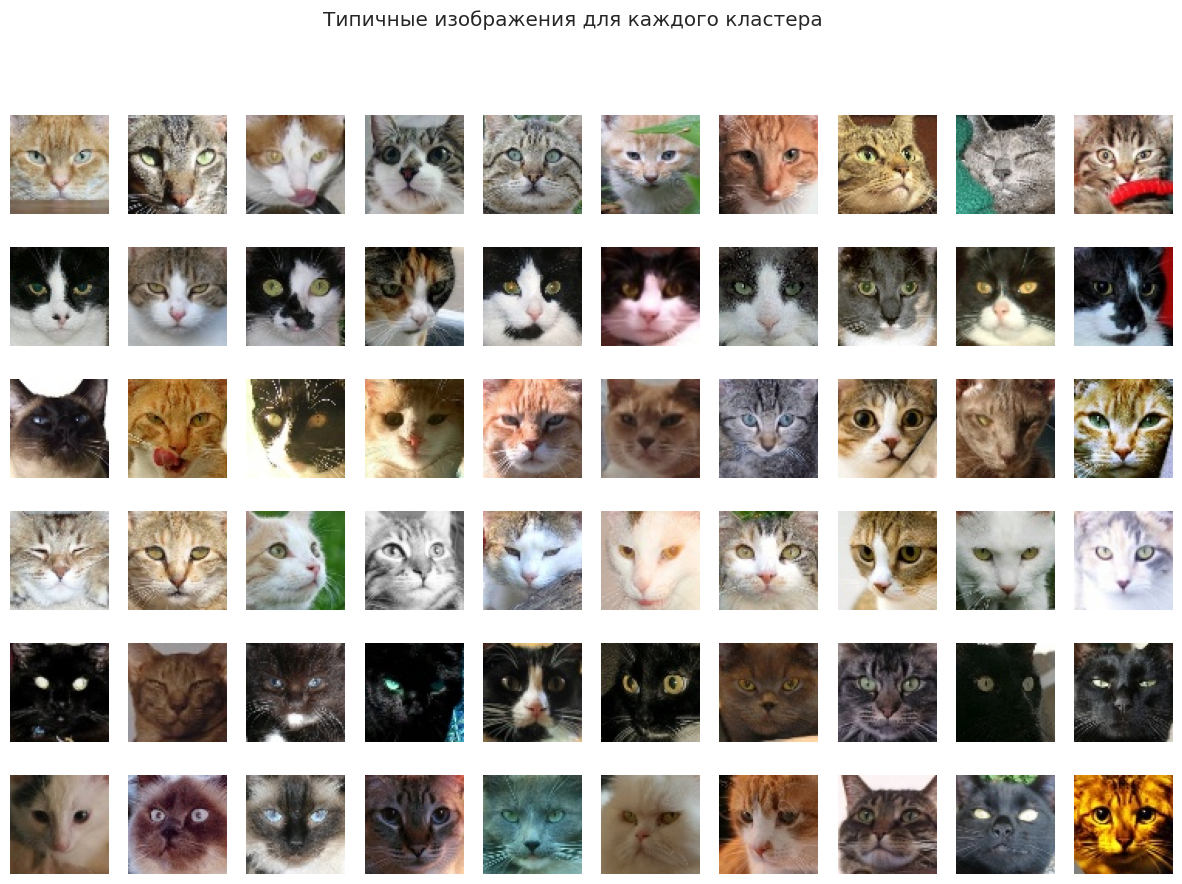

In [24]:
# Визуализация типичных изображений для каждого кластера
visualize_typical_images(cats, y_pred, n_images_per_cluster=10)

Опишите отличительные черты кластеров:

Первый кластер: серенькие коты. Второй кластер: с белой маордочкой на чёрном флоне. Третий кластер: жёлтые, оранжевые. Четвёртый кластер: Белые, серые. Пятый кластер: чёрные коты. Последний кластер: жёлтые, красные, сиамские.

Сильно ли они отличаются от предыдущего способа?

нет.

#### 4. Нейросетевые эмбеддинги + кластеризация

Попробуем применить к изображениям такой же подход, как с текстами. То есть возьмем хорошую уже обученную нейросеть, получим с ее помощью эмбеддинги изображений и будем делать кластеризацию этих эмбеддингов.

Выберите на <a target="_top" href="https://huggingface.co/models">huggingface</a> модель для получения эмбеддингов изображений.

> *Примечания*
> - Нам нужны `CV` модели для задачи извлечения признаков (в фильтрах huggingface называются `Image Feature Extraction`).
> - Не выбирайте слишком тяжелые модели (с суффиксами `-huge`, `-giant`, `-large` и прочим), нам это ни к чему, так как картинки маленькие и простые. К тому же это замедлит предсказание эмбеддингов.
> - Обычно в карточке модели есть пример применения, который можно скопировать и как в семинаре в цикле применить ко всем батчам изображениям.
> - Некоторые модели могут возвращать не эмбеддинг размерности `(D,)`, а матрицу признаков размерности `(n, D)`, в этому случае надо применить average-pooling, усреднив по предпоследней оси.

Загрузите модель, примените к одному тестовому изображению кота и посмотрите на размерность полученного тензора

In [26]:
example_image = cats[0].reshape(64, 64, 3)

import torch
from transformers import ViTFeatureExtractor, ViTModel
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Загрузка модели только с последним слоем
model_name = "google/vit-base-patch16-224"
model = ViTModel.from_pretrained(model_name, output_hidden_states=True).to(device)
processor = ViTImageProcessor.from_pretrained(model_name)

# Пример изображения
example_image = cats[0].reshape(64, 64, 3)
example_image_pil = Image.fromarray(example_image.astype(np.uint8))

# Преобразование изображения
inputs = processor(images=example_image_pil, return_tensors="pt").to(device)

# Получение эмбеддингов
with torch.no_grad():
    outputs = model(**inputs)
    last_hidden_state = outputs.last_hidden_state

# Применение average pooling
embeddings = torch.mean(last_hidden_state, dim=1).squeeze().cpu().numpy()

print(f"Размерность полученного тензора: {embeddings.shape}")

Using device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Размерность полученного тензора: (768,)


Теперь примените загруженную модель ко всем картинкам

Будем обрабатывать батчами, иначе не хватает ОЗУ в colab-е

In [27]:
# Функция для обработки батчами
def process_with_batches(images, batch_size=2):
    all_embeddings = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]

        # Подготовка батча (с изменением размера до 224x224)
        inputs = processor(images=[x.astype(np.uint8) for x in batch], return_tensors="pt", size={"height": 224, "width": 224}).to(device)

        # Прямой проход
        outputs = model(**inputs)

        # Берем только последний скрытый слой
        last_hidden = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(last_hidden.cpu().numpy())

    return np.concatenate(all_embeddings)

In [29]:
# Отключаем ненужные компоненты
model.eval()
torch.set_grad_enabled(False)

# Преобразование и обработка батчами
matrix_cats = np.array([cat.reshape(64, 64, 3).astype(np.uint8) for cat in cats])
emb_cats = process_with_batches(matrix_cats, batch_size=8)

print(f"Embeddings shape: {emb_cats.shape}")

Embeddings shape: (15747, 768)


Сделайте кластеризацию полученных эмбеддингов

In [30]:
# Кластеризация эмбеддингов с использованием K-Means
kmeans = KMeans(n_clusters=6, n_init="auto", random_state=42)
kmeans.fit(emb_cats)
y_pred = kmeans.predict(emb_cats)

Визуализируйте полученные кластера:

In [37]:
# Уменьшение размерности до 2D с использованием PCA
pca_2 = PCA(n_components=2)
cats_projection_2 = pca_2.fit_transform(emb_cats.astype(np.float32))
configure_plotly_browser_state()

#visualize_images_clusterisation(emb_cats, cats_projection_2, y_pred, use_dash=False)

#task7_3.png

Нарисуйте по 5-10 типичных изображений для новых кластеров

In [32]:
reshaped_cats = [cat.reshape(64, 64, 3) for cat in cats]
reshaped_cats = np.array(reshaped_cats)
print(f"Размерность cats: {reshaped_cats.shape}")

Размерность cats: (15747, 64, 64, 3)


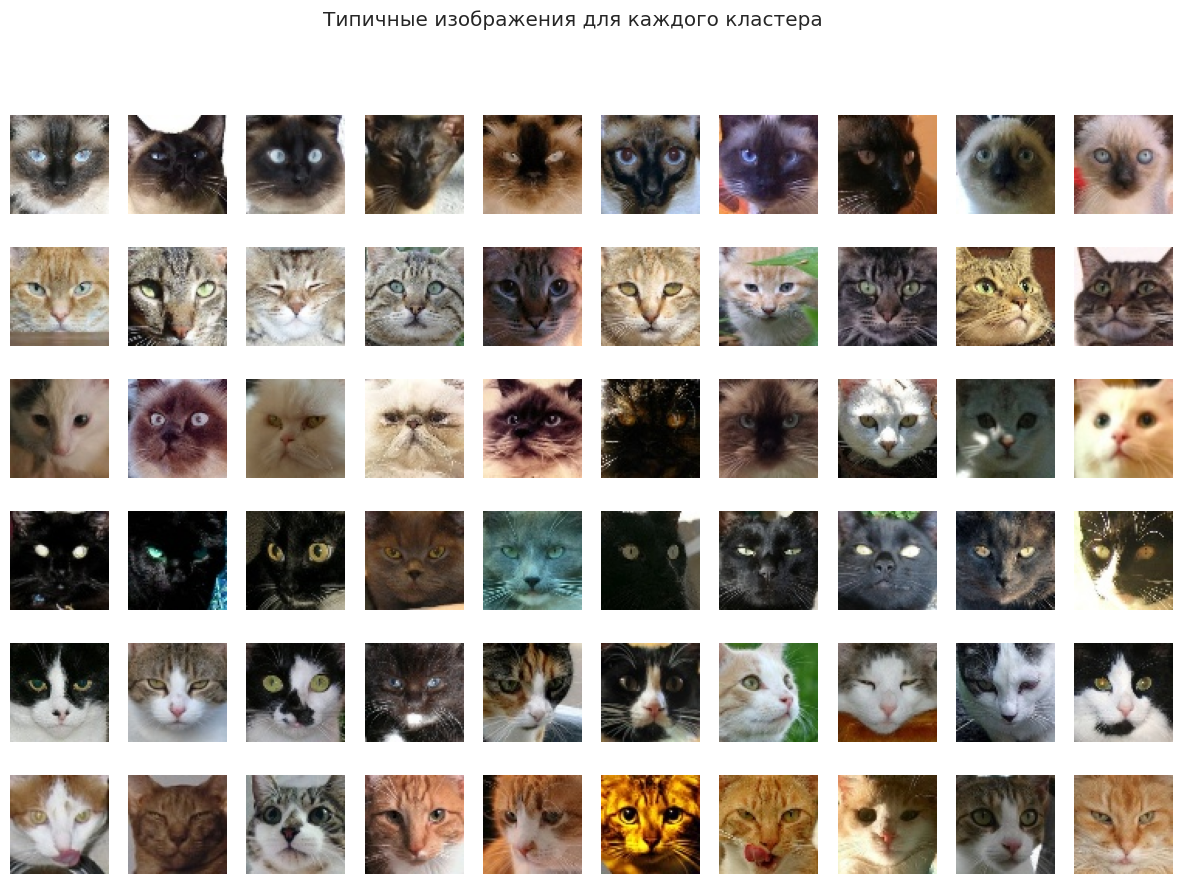

In [33]:
# Функция для визуализации типичных изображений для каждого кластера
def visualize_typical_images(images, labels, n_images_per_cluster=5):
    unique_labels = np.unique(labels)
    fig, axes = plt.subplots(len(unique_labels), n_images_per_cluster, figsize=(15, 10))

    for i, label in enumerate(unique_labels):
        cluster_indices = np.where(labels == label)[0]
        cluster_images = images[cluster_indices]

        # Выбираем n_images_per_cluster изображений, наиболее близких к центроиду
        centroid = kmeans.cluster_centers_[i]
        distances = np.linalg.norm(emb_cats[cluster_indices] - centroid, axis=1)
        closest_indices = cluster_indices[np.argsort(distances)[:n_images_per_cluster]]

        for j, idx in enumerate(closest_indices):
            axes[i, j].imshow(cluster_images[j])
            axes[i, j].axis('off')

    plt.suptitle('Типичные изображения для каждого кластера')
    plt.show()

# Визуализация типичных изображений для каждого кластера
visualize_typical_images(reshaped_cats, y_pred, n_images_per_cluster=10)

Опишите отличительные черты кластеров:

Первый кластер: Сиамские, Второй: usual, Третий: белые, красные. Четвёртый: чёрные, Пятый: сиамские наоборт, Шестой: рыжие.

Чем отличаются кластеры, полученные этим способом от первых двух?

Они более точные. Получилось выделить сиамских от остальных.

#### 5. Выводы
Сделайте выводы:



Была исследована задача кластеризации котов. Метод кластеризации с РСА показал примерно такой же результат, как и метод без РСА. Отличие состояло во времени работы: РСА быстрее. Метод кластеризации с помощью CV модели дал лучший результат. Каждый типичный котик более часто подходит под краткое описание кластера (например, чёрные, или рыжие). Он смог даже отличить сиамских от остальных.